In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("../data/techcrunch.csv")

In [3]:
df.head()

,permalink,company,numEmps,category,city,state,fundedDate,raisedAmt,raisedCurrency,round
0,lifelock,LifeLock,NaN,web,Tempe,AZ,1-May-07,6850000,USD,b
1,lifelock,LifeLock,NaN,web,Tempe,AZ,1-Oct-06,6000000,USD,a
2,lifelock,LifeLock,NaN,web,Tempe,AZ,1-Jan-08,25000000,USD,c
3,mycityfaces,MyCityFaces,7.0,web,Scottsdale,AZ,1-Jan-08,50000,USD,seed
4,flypaper,Flypaper,NaN,web,Phoenix,AZ,1-Feb-08,3000000,USD,a


In [4]:
df.shape

(1460, 10)

In [5]:
df.dtypes

permalink             str
company               str
numEmps           float64
category              str
city                  str
state                 str
fundedDate            str
raisedAmt           int64
raisedCurrency        str
round                 str
dtype: object

In [6]:
df.isna().mean().sort_values(ascending=False)*100

numEmps           61.164384
category           1.643836
city               1.232877
permalink          0.000000
company            0.000000
state              0.000000
fundedDate         0.000000
raisedAmt          0.000000
raisedCurrency     0.000000
round              0.000000
dtype: float64

Vu la proportion de données manquantes dans la colonne numEmps (soit 61.2%), il est préférable de l'omettre dans notre analyse
Pour la colonne category on remplace les données manquantes par ~ unknown et on laisse colonne city avec ses 1.2% de NA 

In [7]:
#Suppression de la colonne numEmp 
df.drop(columns=['numEmps'], errors='ignore', inplace=True)

In [8]:
#remplissage des valeurs manquantes de la colonne category avec la valeur "unknown"
df['category'] = df['category'].fillna('unknown') 

In [24]:
df.columns

Index(['permalink', 'company', 'category', 'city', 'state', 'fundedDate',
       'raisedAmt', 'raisedCurrency', 'round'],
      dtype='str')

In [25]:
df['fundedDate'] = pd.to_datetime(df['fundedDate'], format='%d-%b-%y')

In [26]:
df.isna().sum()

permalink          0
company            0
category           0
city              18
state              0
fundedDate         0
raisedAmt          0
raisedCurrency     0
round              0
dtype: int64

In [27]:
df.dtypes

permalink                    str
company                      str
category                     str
city                         str
state                        str
fundedDate        datetime64[us]
raisedAmt                  int64
raisedCurrency               str
round                        str
dtype: object

## ANALYSE EXPLORATOIRE

In [28]:
df['fundedDate'].dt.year.agg(['min', 'max'])

min    1993
max    2008
Name: fundedDate, dtype: int32

In [29]:
df['fundedDate'].dt.year.value_counts().sort_index()

fundedDate
1993      1
1999     14
2000     17
2001     13
2002     12
2003     27
2004     60
2005    128
2006    253
2007    538
2008    397
Name: count, dtype: int64

In [30]:
df.columns

Index(['permalink', 'company', 'category', 'city', 'state', 'fundedDate',
       'raisedAmt', 'raisedCurrency', 'round'],
      dtype='str')

In [31]:
df["raisedAmt"].describe()

count    1.460000e+03
mean     1.013149e+07
std      1.866146e+07
min      6.000000e+03
25%      2.000000e+06
50%      5.500000e+06
75%      1.102500e+07
max      3.000000e+08
Name: raisedAmt, dtype: float64

 La moyenne des montants levés s'élève à environ 10.1 M$, soit près du double de la médiane (5.5 M$
). Cet écart révèle une distribution asymétrique à droite (vers les grandes valeurs) : quelques méga-levées jusqu'à 300 M$  tirent la moyenne vers le haut, alors que la médiane y reste insensible. Pour décrire une levée de fonds typique dans le README, on retiendra donc la médiane, car elle est insensible aux valeurs extrêmes, contrairement à la moyenne. 

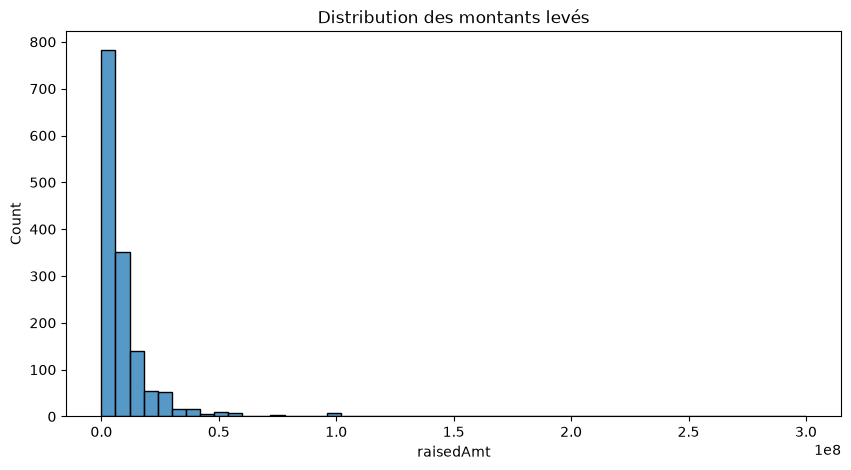

In [32]:
plt.figure(figsize=(10, 5))
sns.histplot(df['raisedAmt'], bins=50)
plt.title('Distribution des montants levés')
plt.show()

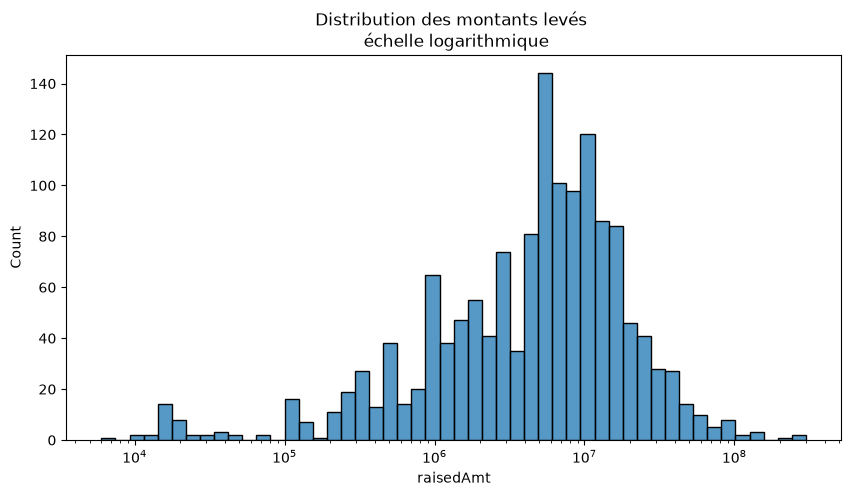

In [33]:
plt.figure(figsize=(10, 5))
sns.histplot(df['raisedAmt'], bins=50, log_scale=True)
plt.title('Distribution des montants levés \n échelle logarithmique')
plt.show()

En échelle naturelle, l'histogramme est illisible : la quasi-totalité des levées s'écrase dans les cinq premières barres, tandis que la longue queue vers les grandes valeurs (jusqu'à 300 M$) laisse le graphique presque vide. Le passage en échelle logarithmique résout le problème car il compresse les écarts entre les petites valeurs (10⁴ $) et les très grandes (10⁸ $), donnant un poids visuel comparable à chaque ordre de grandeur. La distribution révèle alors une forme en cloche quasi symétrique signature d'une distribution dite «log-normale», classique pour des données financières avec un pic entre 1 M$ et 10 M$,cohérent avec la médiane de 5.5 M$ calculée en Q4.

In [34]:
df.groupby('round')['raisedAmt'].median().sort_values(ascending=False)

round
d               24900000.0
e               22000000.0
c               15000000.0
b                9500000.0
unattributed     6100000.0
a                4500000.0
debt_round       2000000.0
angel             800000.0
seed              345000.0
Name: raisedAmt, dtype: float64

In [35]:
df['round'].value_counts()

round
a               582
b               371
c               141
angel           135
seed            128
d                47
unattributed     28
debt_round       17
e                11
Name: count, dtype: int64

In [36]:
df['state'].value_counts(ascending=False).head(10)

state
CA    873
NY    125
MA    107
WA     97
CO     33
TX     25
VA     23
FL     22
PA     21
IL     17
Name: count, dtype: int64

In [37]:
df.groupby('state')['raisedAmt'].agg(['count', 'sum', 'median']).sort_values('sum', ascending=False).head(10)

,count,sum,median
state,,,
CA,873,9361385000,6000000.0
MA,107,1165120000,7000000.0
NY,125,890185000,4500000.0
WA,97,789590000,5900000.0
MD,8,351750000,9700000.0
FL,22,305818000,4000000.0
VA,23,266400000,10000000.0
CT,13,232645000,1200000.0
TX,25,220125000,4500000.0


In [38]:
import plotly.express as px

state_totals = df.groupby('state')['raisedAmt'].sum().reset_index()
state_totals['raisedAmt_Md'] = (state_totals['raisedAmt'] / 1e9).round(2)

fig = px.treemap(state_totals, path=['state'], values='raisedAmt',
                 custom_data=['raisedAmt_Md'],
                 title='Montants levés par état — la domination californienne')
fig.update_traces(hovertemplate='<b>%{label}</b><br>%{customdata[0]} Md$<extra></extra>')
fig.show()

In [39]:
import pandas as pd
import plotly.express as px

# Agrégation par État
state_totals = (
    df.groupby("state", as_index=False)["raisedAmt"]
      .sum()
)

# Conversion en milliards de dollars
state_totals["raisedAmt_Md"] = (
    state_totals["raisedAmt"] / 1e9
).round(2)

# Dictionnaire État -> Région
regions = {
    # West
    "CA": "West", "WA": "West", "OR": "West",
    "NV": "West", "AZ": "West", "UT": "West",
    "CO": "West",

    # Northeast
    "NY": "Northeast", "MA": "Northeast",
    "NJ": "Northeast", "CT": "Northeast",
    "PA": "Northeast", "NH": "Northeast",

    # South
    "TX": "South", "FL": "South",
    "GA": "South", "NC": "South",
    "VA": "South", "MD": "South",

    # Midwest
    "IL": "Midwest", "OH": "Midwest",
    "MI": "Midwest", "MN": "Midwest",
    "WI": "Midwest", "MO": "Midwest"
}

# Ajout de la région
state_totals["region"] = (
    state_totals["state"]
    .map(regions)
    .fillna("Other")
)

# Treemap
fig = px.treemap(
    state_totals,
    path=["region", "state"],
    values="raisedAmt",
    color="region",
    color_discrete_map={
        "West": "#1f77b4",
        "Northeast": "#ff7f0e",
        "South": "#2ca02c",
        "Midwest": "#d62728",
        "Other": "#7f7f7f"
    },
    custom_data=["raisedAmt_Md", "region"],
    title="Montants levés par région et par État"
)

# Texte affiché dans les rectangles
fig.update_traces(
    texttemplate="<b>%{label}</b><br>%{customdata[0]} Md$",
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Région : %{customdata[1]}<br>"
        "Montant : %{customdata[0]} Md$"
        "<extra></extra>"
    )
)

fig.update_layout(
    margin=dict(t=60, l=10, r=10, b=10)
)

fig.show()

Cette cartographie (treemap) met en évidence l'asymétrie de la répartition géographique du capital-risque. La structure du marché est caractérisée par une forte polarisation : la Californie capte à elle seule plus de la moitié des ressources, devançant un second pôle restreint (Massachusetts, New York, Washington), tandis que le reste des États forme une longue traîne aux financements marginaux. Néanmoins, cette hégémonie en valeur absolue doit être nuancée par l'analyse des valeurs médianes. Sur ce segment, le Massachusetts surclasse la Californie, illustrant qu'une concentration du volume global n'implique pas mécaniquement une supériorité quant à la taille unitaire des transactions.

La levée médiane s'élève à 7 millions de dollars dans le Massachusetts, contre 6 millions en Californie et 4,5 millions à New York. Cette suprématie du Massachusetts en ticket médian doit toutefois être nuancée : elle repose sur 107 deals seulement, contre 873 pour la Californie. Une médiane calculée sur huit fois moins de transactions reste plus sensible à quelques grosses levées, là où celle de la Californie, appuyée sur un volume massif, est bien plus robuste.

## ANALYSE TEMPORELLE

In [41]:
temp = df.set_index('fundedDate').resample('QE')['raisedAmt'].agg(['count', 'sum'])


In [42]:
temp

,count,sum
fundedDate,,
1993-09-30,1,125000
1993-12-31,0,0
1994-03-31,0,0
1994-06-30,0,0
1994-09-30,0,0
...,...,...
2007-09-30,145,1662640000
2007-12-31,137,1797328000
2008-03-31,181,1995683750


In [43]:
temp.head(5)

,count,sum
fundedDate,,
1993-09-30,1,125000
1993-12-31,0,0
1994-03-31,0,0
1994-06-30,0,0
1994-09-30,0,0


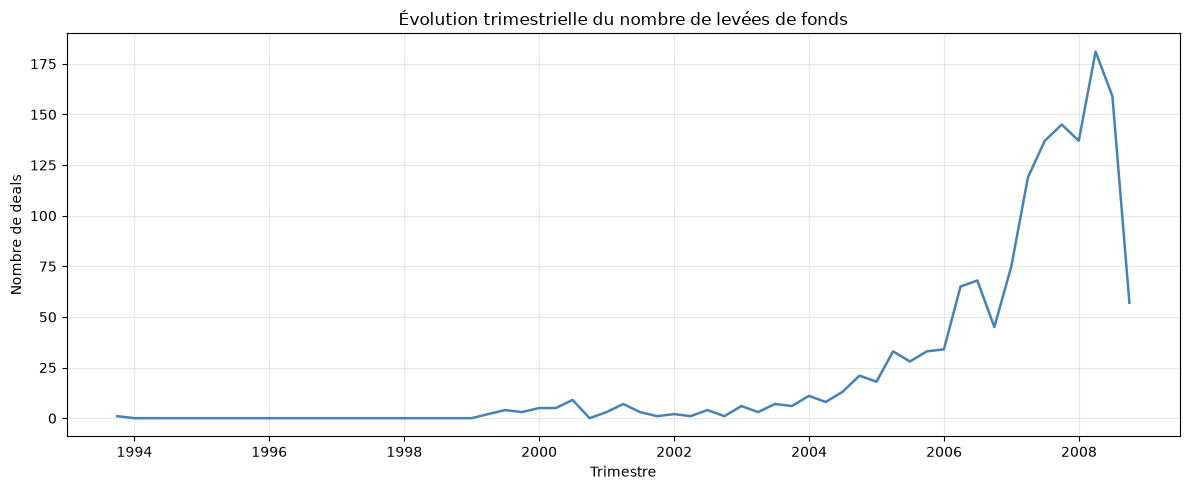

In [44]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(temp.index, temp['count'], color='steelblue', linewidth=1.8)

ax.set_title('Évolution trimestrielle du nombre de levées de fonds')
ax.set_xlabel('Trimestre')
ax.set_ylabel('Nombre de deals')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()